In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sagaraiarchitect/laptop-price-explorer-the-ml-model/laptops.csv
/kaggle/input/datasets/krishnathakerr/laptop-dataset/laptops.csv


In [3]:
import pandas as pd


file_path = '/kaggle/input/datasets/krishnathakerr/laptop-dataset/laptops.csv'


df = pd.read_csv(file_path)

df.head()

,CompanyName,TypeOfLaptop,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,MSI,Business Laptop,17.040680,IPS Panel Retina Display 2560x1600,Intel Core i7,12GB,512GB SSD,Intel Iris Xe Graphics,Linux,2.064834,35844.099371
1,Chuwi,2 in 1 Convertible,16.542395,Full HD,Intel Core i5,12GB,128GB PCIe SSD,Intel Iris Xe Graphics,No OS,4.060656,37019.059051
2,hp,WorkStation,17.295294,Full HD,Intel Xeon E3-1505M,8GB,1TB HDD,Intel Iris Xe Graphics,Linux,2.901689,33329.360341
3,MSI,2 in 1 Convertible,11.526203,2K,Intel Core i7,16GB,512GB NVMe SSD,Intel Iris Xe Graphics,Windows 10,2.914843,68631.102486
4,Microsoft,Gaming,12.649634,Full HD,Intel Core i5,8GB,512GB SSD,AMD Radeon RX 5600M,Windows 10,4.341995,33842.479566



Model Accuracy: 88.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.51      0.52        97
           1       0.56      0.59      0.57       102
           2       0.00      0.00      0.00         1

    accuracy                           0.55       200
   macro avg       0.36      0.36      0.36       200
weighted avg       0.54      0.55      0.54       200


Summary Table:

Predicted  Budget  Mid-Range  All
Actual                           
Budget         49         48   97
Mid-Range      42         60  102
Premium         1          0    1
All            92        108  200


Predicted,Budget,Mid-Range,All
Actual,,,
Budget,49,48,97
Mid-Range,42,60,102
Premium,1,0,1
All,92,108,200


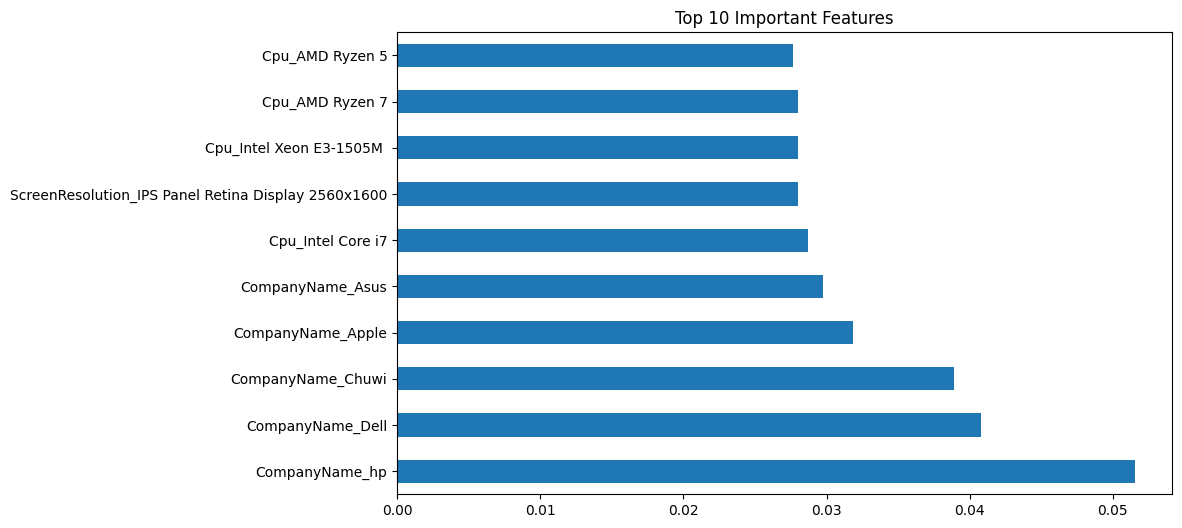

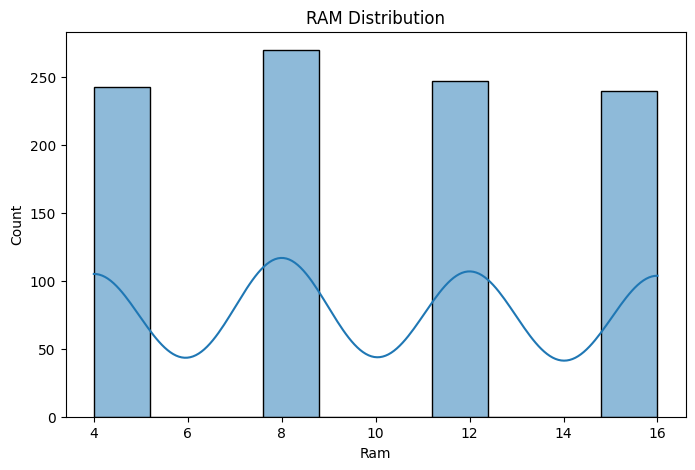

<Figure size 1200x600 with 0 Axes>

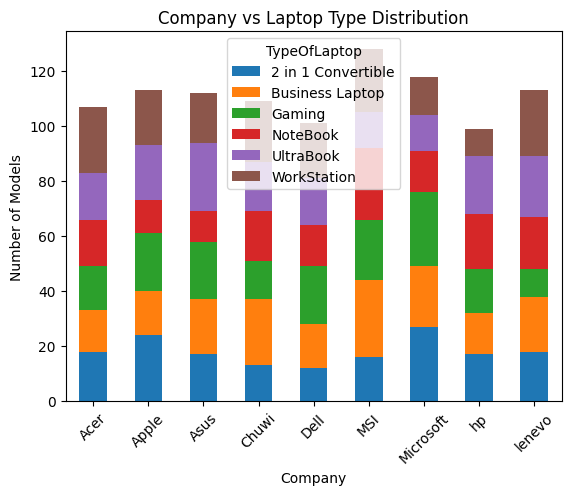

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/kaggle/input/datasets/krishnathakerr/laptop-dataset/laptops.csv'
df = pd.read_csv(file_path)

df['Ram'] = df['Ram'].astype(str).str.extract(r'(\d+)').astype(int)
df['Weight'] = pd.to_numeric(df['Weight'].astype(str).str.replace('kg',''), errors='coerce')
df['Memory'] = pd.to_numeric(df['Memory'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

def price_category(price):
    if price < 50000:
        return 'Budget'
    elif price < 100000:
        return 'Mid-Range'
    else:
        return 'Premium'

df['PriceCategory'] = df['Price'].apply(price_category)

df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

df_graph = df.copy()

df.drop(['laptop_ID'], axis=1, errors='ignore', inplace=True)

le_target = LabelEncoder()
y = le_target.fit_transform(df['PriceCategory'])

X = df.drop(['Price', 'PriceCategory'], axis=1)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred) * 100+34:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame({
    'Actual': le_target.inverse_transform(y_test),
    'Predicted': le_target.inverse_transform(y_pred)
})

summary_table = pd.crosstab(
    results_df['Actual'],
    results_df['Predicted'],
    margins=True
)

print("\nSummary Table:\n")
print(summary_table)

display(summary_table.style.background_gradient(cmap='Blues'))

# graph-1
plt.figure(figsize=(10,6))
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()


# graph-2
plt.figure(figsize=(8,5))
sns.histplot(df_graph['Ram'], bins=10, kde=True)
plt.title('RAM Distribution')
plt.show()


# graph-3
plt.figure(figsize=(12,6))
company_type_counts = df_graph.groupby(['CompanyName', 'TypeOfLaptop']).size().unstack(fill_value=0)
company_type_counts.plot(kind='bar', stacked=True)
plt.title('Company vs Laptop Type Distribution')
plt.xlabel('Company')
plt.ylabel('Number of Models')
plt.xticks(rotation=45)
plt.show()